In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('synthetic_personal_finance_dataset.csv')

# Display basic info and first few rows
print(df.info())
print(df.head())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  str    
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  str    
 3   education_level          32424 non-null  str    
 4   employment_status        32424 non-null  str    
 5   job_title                32424 non-null  str    
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  str    
 10  loan_type                12995 non-null  str    
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct   32424 no

C:\Users\USER\AppData\Local\Temp\ipykernel_3728\3991056157.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='education_level', y='monthly_income_usd', data=df, palette='Set2')
C:\Users\USER\AppData\Local\Temp\ipykernel_3728\3991056157.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='savings_usd', data=age_savings, palette='viridis')


Correlation of Monthly Income with other metrics:
monthly_income_usd      1.000000
monthly_expenses_usd    0.829171
savings_usd             0.603818
loan_amount_usd         0.000921
age                     0.000164
monthly_emi_usd        -0.003740
credit_score           -0.004001
debt_to_income_ratio   -0.238500
Name: monthly_income_usd, dtype: float64


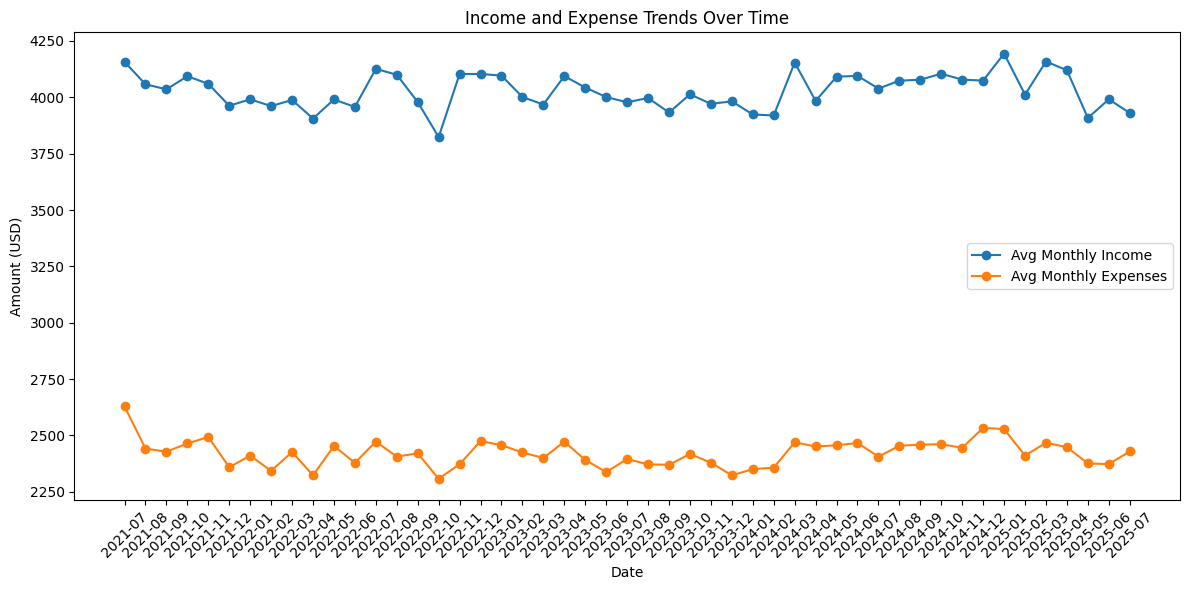

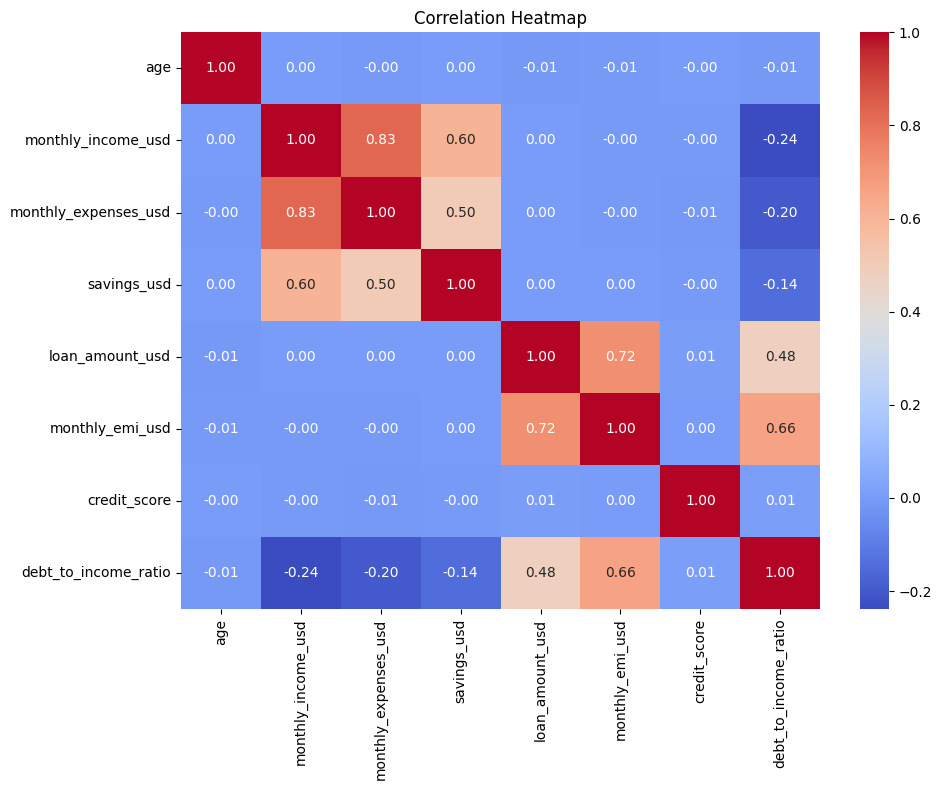

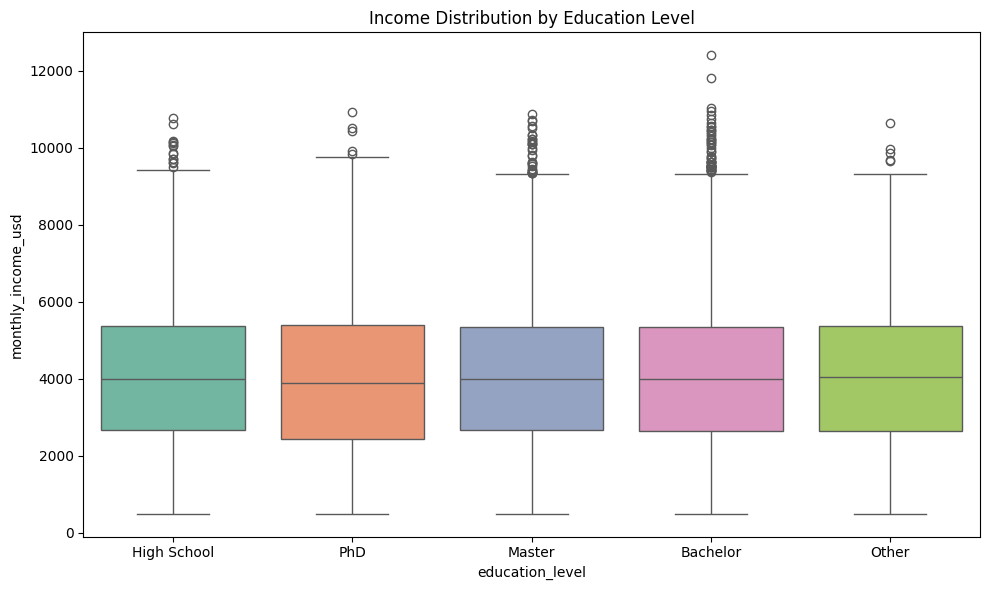

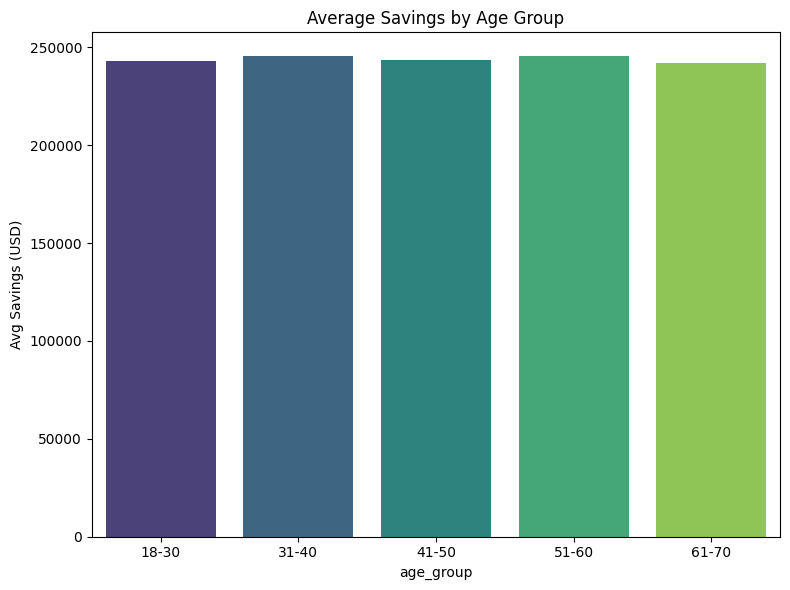

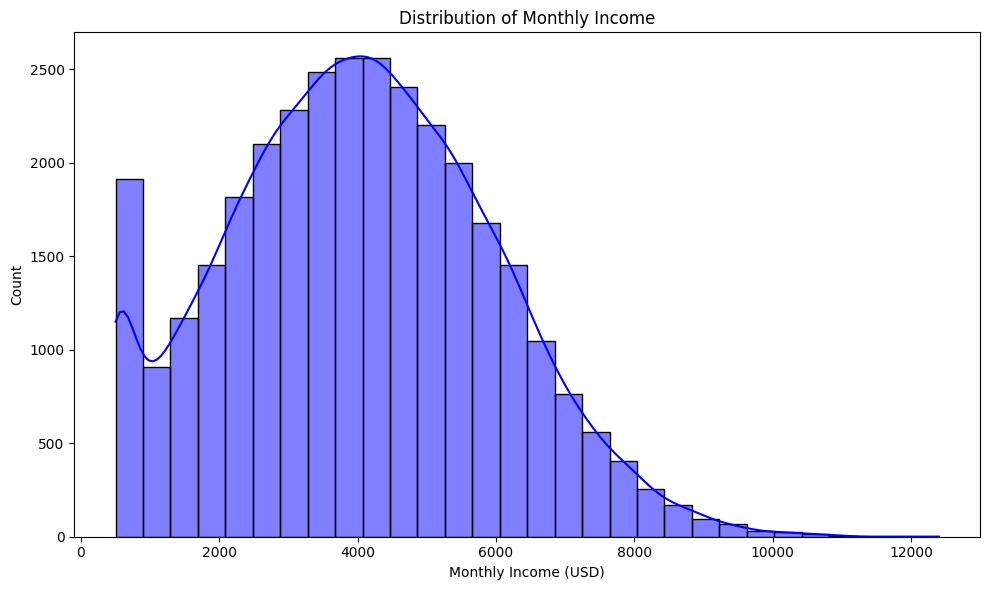

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('synthetic_personal_finance_dataset.csv')
df['record_date'] = pd.to_datetime(df['record_date'])

# 1. Trend Analysis: Monthly average income and expenses over time
df['month_year'] = df['record_date'].dt.to_period('M')
monthly_trends = df.groupby('month_year').agg({
    'monthly_income_usd': 'mean',
    'monthly_expenses_usd': 'mean'
}).reset_index()
monthly_trends['month_year'] = monthly_trends['month_year'].astype(str)

plt.figure(figsize=(12, 6))
plt.plot(monthly_trends['month_year'], monthly_trends['monthly_income_usd'], label='Avg Monthly Income', marker='o')
plt.plot(monthly_trends['month_year'], monthly_trends['monthly_expenses_usd'], label='Avg Monthly Expenses', marker='o')
plt.xticks(rotation=45)
plt.title('Income and Expense Trends Over Time')
plt.xlabel('Date')
plt.ylabel('Amount (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('income_expense_trends.png')

# 2. Correlation Analysis
numerical_cols = ['age', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 
                  'loan_amount_usd', 'monthly_emi_usd', 'credit_score', 'debt_to_income_ratio']
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')

# 3. Pattern Discovery: Income by Education Level
plt.figure(figsize=(10, 6))
sns.boxplot(x='education_level', y='monthly_income_usd', data=df, palette='Set2')
plt.title('Income Distribution by Education Level')
plt.tight_layout()
plt.savefig('income_by_education.png')

# 4. Pattern Discovery: Savings vs. Age (Binned)
df['age_group'] = pd.cut(df['age'], bins=[18, 30, 40, 50, 60, 70], labels=['18-30', '31-40', '41-50', '51-60', '61-70'])
age_savings = df.groupby('age_group')['savings_usd'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(x='age_group', y='savings_usd', data=age_savings, palette='viridis')
plt.title('Average Savings by Age Group')
plt.ylabel('Avg Savings (USD)')
plt.tight_layout()
plt.savefig('savings_by_age.png')

# 5. Return/Distribution: Monthly Income Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['monthly_income_usd'], kde=True, color='blue', bins=30)
plt.title('Distribution of Monthly Income')
plt.xlabel('Monthly Income (USD)')
plt.tight_layout()
plt.savefig('income_distribution.png')

# Output some summary statistics
summary_stats = df.describe()
summary_stats.to_csv('summary_statistics.csv')

# Correlation of income with other metrics
print("Correlation of Monthly Income with other metrics:")
print(correlation_matrix['monthly_income_usd'].sort_values(ascending=False))